# Interim 8-Day Composite Primary Productivity (NetPP) Algorithm
> History | Updated Dec 2024

## Background

**Net primary productivity in the ocean is the rate at which phytoplankton store energy as biomass and make it available to other consumers in an ecosystem.**

* It is typically reported in units like mg C/m2/day

* It is driven by photosynthesis where phytoplankton use light energy to convert $\text{CO}_2$ into organic carbon.

**Productivity measurements happen in the field, usually on a research cruise.**

* Water is collected at several depths in the water column.

* The water is spiked with radiolabeled C ($C^{14}$), and incubated over a range of light levels for 24 hours.

* The rate of radiolabeled C ending up in pythoplankton cells is used to determine net primary productivity.

**The 1997 Behrenfeld and Falkowski algorithm estimates primary productivity using satellite measurements.**

* The algorithm uses three satellite measurements:

    * chlorophyll_a (Chl) https://en.wikipedia.org/wiki/Chlorophyll_a

    * sea surface temperature (SST)

    * photosynthetically active radiation (PAR) https://en.wikipedia.org/wiki/Photosynthetically_active_radiation

* The type of model is called a Vertically Generalized Production Model (VGPM). https://en.wikipedia.org/wiki/Vertically_Generalized_Production_Model

### **The algorithm formulation is listed below:**

> $PP_{eu} = 0.66125 \times P_{opt}^b \times \frac{PAR^o}{PAR^o + 4.1} \times Z_{eu} \times CHL \times DL$
>
> ### Where:

* CHL = chlorophyll a concentration at surface (mg m^-3)
* DL = Daylight hours - (hours)
* $Z_{eu}$ = the depth where light is 1% of that at the surface - Units: meters (m)
* $P_{opt}^b$ Maximum C fixation rate within the water column - Units: mg C (mg Chl)-1 h-1
* PAR = Photosynthetically Active Radiation - Units: Daily average insitu par (Einstein m-2 d-1)

### Several of these parameters can be determined with satellite data

$P_{opt}^b$ is derived from SST using the seventh order polynomial of Behrenfeld and Falkowski (1997).

> $P_{opt}^b = -3.27E-8 \cdot T^7 + 3.4132E-6 \cdot T^6 - 1.348E-4 \cdot T^5 + 2.462E-3 \cdot T^4 - 0.0205 \cdot T^3 + 0.0617 \cdot T^2 + 0.2749 \cdot T$

* Where T = temperature in Celsius (℃)


$Z_{eu}$ is derived from an estimate of the total chlorophyll concentration within the euphotic layer ($CHL_{eu}$) based on the Case I models of Morel and Berthon (1989):

> $Z_{eu} = 568.2 \cdot CHL^{-0.746} \quad \text{when } CHL_{eu} > 10.0$
>
> or
>
> $Z_{eu} = 200.0 \cdot CHL^{-0.293} \quad \text{when } CHL_{eu} \leq 10.0$

> Where:
>
> - $CHL_{eu} = 38.0 \cdot CHL^{0.4250} \quad \text{when } CHL \leq 1.0$
> - or
> - $CHL_{eu} = 40.2 \cdot CHL^{0.5070} \quad \text{when } CHL > 1.0$

## Objective

Create primary productivity satellite-based products.

This script generates primary productivity fields from chlorophyll, SST, PAR
satellite data using the method of Behrenfeld and Falkowski 1997. It accepts
source satellite data that has been gridded to the NASA 9km SMI.
NOAA CoastWatch standard ocean color grid. As written, the script is tailored
for pairing the following global, daily input data to produce
primary productivity fields:

* **NASA NOAA20-VIIRS chlorophyll and PAR**
* **NASA NOAA21-VIIRS chlorophyll and PAR**
* **SST from the NOAA Gridded Super-collated product**

Users set the satellite input data, start dates and stop date
via command-line arguments.

The output files are created by generating a template netCDF file from a cdl
file that is prepopulated with metadata but has only latitude and longitude
data. The template file is populated with the primary productivity data
and then renamed.

The script can be repurposed for different input data with these modifications:

* Gridding any input chlorophyll, PAR, and SST data to a common grid.

* Creating an appropriate cdl file for the dataset.

* Adjusting the logic to make directory paths.

* Adjust output file naming and input file search pattern.

> ### **Steps:**
>
> **Directory Setup**
>
> * Ensure all required directories are created dynamically based on the input parameters.
>
> **Download Data**
>
> * Download CHL, PAR, and SST data.
>
> * Regrid SST to match NASA's 4km grid using CoastWatch Utilities.
>
> **NetPP Calculations**
>
> * Load datasets (CHL, PAR, SST).
>
> * Calculate:
>   * $P_{opt}^b$ : Chlorophyll-specific productivity.
>
>   * $Z_{eu}$ : Euphotic depth.
>
>   * DL: Daylength.
>      
>   * NetPP using the Behrenfeld-Falkowski algorithm.
>
> **Save NetPP Output**
>
> * Generate a NetCDF file for each date, populated with calculated fields and metadata.
>
> * Compress the NetCDF file and move it to the target directory.
>
> **Visualize the NetPP data**
> 
> * Create global plots of NetPP, SST, CHL, & PAR
>
> * Plot $P_{opt}^b$ as a function of SST

### Resource Requirements

* Jupyter Notebook.

* Python 3 with the modules included within the "Import packages" section below.

* Template CDL file that is prepopulated with metadata but has only latitude and longitude data.

* Internet connection.

* NASA Earth Data Credentials?

## Import Packages

In [1]:
import os
import xarray as xr
import requests
import ntpath
import numpy as np
import numpy.ma as ma
from netCDF4 import Dataset
import matplotlib.pyplot as plt

%matplotlib inline
import pandas as pd
import subprocess
from datetime import timedelta, datetime, timezone
import sys
from dateutil.parser import parse
import warnings

warnings.filterwarnings("ignore")

## Create global variables

Global variables are used to set up the file structure, directory paths, and template files required for processing NetPP.

In [2]:
ROOT_DIR = "/Users/madisonrichardson/netpp"
CHL_DIR_T = os.path.join(ROOT_DIR, "data/{}/chl/8_day_chl")
PAR_DIR_T = os.path.join(ROOT_DIR, "data/{}/par/8_day_par")
SST_DIR_T = os.path.join(ROOT_DIR, "data/{}/sst/{}")
WORK_DIR = os.path.join(ROOT_DIR, "work")
BIN_DIR = os.path.join(ROOT_DIR, "bin")
RES_DIR = os.path.join(ROOT_DIR, "resources")
NC_OUT_DIR_T = os.path.join(ROOT_DIR, "data/{}/netpp/8_day_netpp")
CDL_IN_FILE = "composite.cdl"
TEMP_OUT_FILE = "composite.nc"

## Create useful functions

### Generate NOAA-21 WGET URLs
* The function creates a list of file URLs for NOAA21 VIIRS 8-day composite data.

In [3]:
def make_n21_filelist(file_date_ranges, prefix, p_id):
    """
    Generate a list of file URLs for NOAA21 VIIRS 8-day composite data.

    This function constructs URLs for NOAA21 VIIRS data files
    using a base URL, date ranges, a specified file prefix,
    and a product ID. The generated URLs are formatted to
    match the file naming convention for 8-day composites.

    Args:
        file_date_ranges (list of str): A list of date ranges formatted as
        strings (e.g.  '20230407-20230414') representing the 8-day periods.
        prefix (str): The prefix for the file type (e.g., 'SST', 'CHL').
        p_id (str): The product ID to specify the type of data (e.g., 'PAR').

    Returns:
        list of str: A list of full URLs to the data files.
    """
    b_url = "http://oceandata.sci.gsfc.nasa.gov/getfile/"
    fl_list = [
        b_url + f"JPSS2_VIIRS.{fdr}.L3m.8D.{prefix}.{p_id}.9km.NRT.nc"
        for fdr in file_date_ranges
    ]

    return fl_list

### Generate the NASA data file list
* The function generates and downloads a list of NASA data file for NOAA20 VIIRS 8-day composite data.

In [4]:
def download_nasa20_file_list(start_date, end_date, data_type, directory):
    """
    Download list if NASA data files for NOAA20.

    Args_:
        start_date (datetime): First date of time series to process.
        end_date (datetime): Last date of time series to process.
        data_type (str): The type of data to download, either
                        'chlorophyll' or 'par'.
        directory (str): The directory where the downloaded data will be saved.
                         The word dir is recommended

    Returns_:
        Path to the downloaded NASA file list.
    """

    # Validate data type
    if data_type == "chlorophyll":
        prod_id = "chlor_a"
    elif data_type == "par":
        prod_id = "par"
    else:
        raise ValueError("data_type must be 'chlorophyll' or 'par'")

    # Extract the start and end dates for the 8-day composite
    sdate = start_date.strftime("%Y%m%d")
    edate = end_date.strftime("%Y%m%d")

    dtid = "1197"
    wget_template = " ".join(
        [
            "wget",
            "-q",
            '--post-data="results_as_file=1&sensor_id=33&dtid={}&sdate={}&edate={}',
            '&subType=1&addurl=1&prod_id={}&resolution_id=9km&period=8D"',
            "-O {}",
            "https://oceandata.sci.gsfc.nasa.gov/api/file_search",
        ]
    )

    # File name for list of files
    file_list_name = f"{data_type}_nasa_file_list_" f"{sdate}_{edate}.txt"
    file_list_path = os.path.join(directory, file_list_name)

    # Format wget command for retrieving file list
    nasa_wget = wget_template.format(
        dtid, sdate, edate, prod_id, file_list_path
    )
    subprocess.call(nasa_wget, shell=True)

    return file_list_path

### Download data from NASA

* Download data files (chlorophyll or PAR) from NASA's Ocean Biology Processing Group services using a file URL.

In [5]:
def download_nasa_data_dhr(file_url, directory):
    """
    Download NASA data files for specified sensor.

    Downloads chlorophyll and PAR data files from NASA's
    Ocean Biology Processing Group services using a provided
    file URL. It uses wget with cookie-based authentication to
    access protected resources. The downloaded file is saved
    to the specified directory.

    Args_:
        file_url (str): The URL of the file to download.
        directory (str): The target directory where the
        downloaded file will be saved

    Returns_:
        str: The full path to the downloaded file if successful.
        None: If the download fails.
    """

    # File name for the downloaded file
    import ntpath

    target_file_name = ntpath.basename(file_url)

    downloaded_file_path = os.path.join(directory, target_file_name)

    # Command to download the file using wget with cookies
    wget_Cmd = (
        f"wget --load-cookies ~/.urs_cookies --save-cookies ~/.urs_cookies "
        f"--auth-no-challenge=on --content-disposition "
        f"-O {downloaded_file_path} {file_url}"
    )

    # Print generated wget command and dates
    print(wget_Cmd)
    print("downloaded = zero", subprocess.call(wget_Cmd, shell=True))

    # Verify if the file was downloaded
    if os.path.exists(downloaded_file_path):
        print("Downloaded:", target_file_name)
        return downloaded_file_path
    else:
        print("Failed to download data", target_file_name)

### Calculate the running mean
* Calculates the running mean iteratively by incorporating a new set of observation ('obs') into the current mean and count of valid observations.

In [6]:
def meanVar(mean, num, obs):
    """
    Adjusts the running mean and number of valid
    observations by incorporating a new observation
    set ('obs'). It handles masked arrays, ensuring
    that missing or invalid values do not affect the
    mean calculation.

    Args:
        mean (numpy.ndarray): The current mean array, to be updated.
        num (numpy.ndarray): An array that keeps track of the number
                            of valid observations per element.
        obs (numpy.ma.MaskedArray): The new set of observations to
                                    update the mean and count.

    Returns:
        tuple:
            - numpy.ndarray: The updated mean array.
            - numpy.ndarray: The updated count of valid
                            observations array.
    """
    numShape = num.shape
    temp = np.subtract(obs, mean, dtype=np.single)
    numAdd = np.ones(numShape, dtype=np.int32)

    my_mask = ma.getmask(obs)
    numAdd = ma.masked_array(numAdd, mask=my_mask)
    numAdd = numAdd.filled(fill_value=0)

    # numAdd[obs.mask] = 0
    num = np.add(num, numAdd, dtype=np.int32)
    tempNum = ma.array(num, mask=(num == 0), dtype=np.int32)
    tNfloat = tempNum.astype("float")

    temp = np.divide(temp, tNfloat, dtype=np.single)
    # temp = np.divide(temp, tempNum.astype('float'), dtype=np.single)
    mean = np.add(mean, temp.filled(0.0), dtype=np.single)

    return (mean, num)

### Calculates maximum chlorophyll-specific productivity ($P_{opt}^b$) using a 7th order polynomial

In [7]:
def calculate_PbOpt(sst_data_mod):
    """Calculate the maximum chlorophyll fixation rate.

    Calculates the maximum chlorophyll fixation rate (PbOpt) within the
    water column based on modified SST data using a seventh-order
    polynomial equation.

    Args_:
        sst_data_mod (ndarray or float): Modified SST where SST < -1 equal
            to the value at -1 and to set all values where SST > 29 equal to
            the value at 29. This can either be a single value or a numpy
            array of SST values.

    Returns_:
        ndarray or float: The calculated maximum chlorophyll fixation rate
                        (PbOpt) (units: mg C (mg chl)^-1 h^-1) corresponding
                        to the input SST data. The return matches the input
                        data meaning if a single value is inputted, a float
                        is returned, or if the input is an array, a numpy
                        array is returned.

    """
    return (
        -3.27e-8 * sst_data_mod**7
        + 3.4132e-6 * sst_data_mod**6
        - 1.348e-4 * sst_data_mod**5
        + 2.462e-3 * sst_data_mod**4
        - 0.0205 * sst_data_mod**3
        + 0.0617 * sst_data_mod**2
        + 0.2749 * sst_data_mod
        + 1.2956
    )

### Computes euphotic depth ($Z_{eu}$) based on chlorophyll concentration

In [8]:
def calculate_Z_eu(chl):
    """Calculate the euphotic depth.

    Calculates the euphotic depth where light is 1% of that at the surface
    (Z_eu) based on chlorophyll-a concentration (CHL_eu) using the Case I
    models of Morel and Berthon (1989).

    Args_:
        chl (xarray.DataArray or ndarray): Chlorophyll-a concentration
                                                (mg m^-3). The input can be
                                                either an xarray.DataArray or
                                                a numpy array.

    Return_:
        xarray.DataArray or ndarray: The calculated euphotic depth (Z_eu) in
                                    meters, where the return type matches the
                                    input type.

    """
    chl_eu = ma.where(chl > 1.0, 40.2 * chl**0.5070, 38.0 * chl**0.4250)

    Z_eu = ma.where(
        chl_eu > 10.0, 568.2 * chl_eu**-0.746, 200.0 * chl_eu**-0.293
    )

    return Z_eu

### Computes daylight hours (DL) based on latitude and 5th day of the 8-day period

In [9]:
def daylength(dayOfYear, lat):
    """Determine the length of the daylight period.

    Computes the length of the day (the time between sunrise and
    sunset) given the day of the year and latitude of the location.
    Function uses the Brock model for the computations.
    For more information see, for example,
    Forsythe et al., "A model comparison for daylength as a
    function of latitude and day of year", Ecological Modelling,
    1995. Modified (vectorize) from by Dale Robinson:
    https://gist.github.com/anttilipp/ed3ab35258c7636d87de6499475301ce

    Args_:
        dayOfYear (int): The day of the year, where 1 corresponds to
            the 1st of January.

        lat (ndarray): A numpy array of latitude of the pixel location
        in decimal degrees.
            Positive values for north and negative for south.

    Return:_
        day_len (ndarray): A numpy array of daylength in decimal hours,
            e.g 12:30pm is 12.5.
    """
    # Calculate the  center day for the 8-day composite
    # Center day is the 5th day of the 8-day period
    center_dayOfYear = dayOfYear + 4

    # Correct for leap year
    if dayOfYear == 366:
        dayOfYear = 365

    latInRad = np.deg2rad(lat)
    declinationOfEarth = 23.45 * np.sin(
        np.deg2rad(360.0 * (283.0 + center_dayOfYear) / 365.0)
    )

    cos_hour_angle = -np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth))
    cos_hour_angle = np.clip(cos_hour_angle, -1.0, 1.0)

    hourAngle = np.rad2deg(np.arccos(cos_hour_angle))

    day_len = 2.0 * hourAngle / 15.0
    day_len = np.where(cos_hour_angle <= -1.0, 24, day_len)
    day_len = np.where(cos_hour_angle >= 1.0, 0, day_len)

    return day_len

### Calculates NetPP ($PP_{eu}$)based on input variables

In [10]:
def calculate_PPeu(chl, Pbopt, Z_eu, par, day_len_2d):
    """Calculate the daily depth-integrated primary production.

    Calculates the daily depth-integrated primary production (PP_eu) using
    a Vertically Generalized Production Model (VGPM).

    Args_:
        chl (xarray.DataArray or ndarray): Chlorophyll-a concentration
            (mg m^-3).
        Pbopt (xarray.DataArray or ndarray): Maximum chlorophyll fixation rate
            (PbOpt) (mg C (mg chl)^-1 h^-1).
        Z_eu (xarray.DataArray or ndarray): Euphotic depth (Z_eu) in meters.
        par (xarray.DataArray or ndarray): Photosynthetically ACtive
        Radiation (PAR) (Einstein m^-2 d^-1).
        day_len_2d (xarray.DataArray or ndarray): Length of the daylight
            period expanded into a 2D array to match the dimensions
            of the other inputs.

    Returns_:
        xarray.DataArray or ndarray: The calculated primary production (PP_eu)
            (mg C m^-2 d^-1), with the return type matching the input types.

    """
    par_ratio = par / (par + 4.1)
    PPeu = 0.66125 * Pbopt * par_ratio * Z_eu * chl * day_len_2d
    return PPeu

## Input Parameters and Metadata

* Define the input parameters such as start and end dates, sensor type (NOAA20 or NOAA21), overwrite settings, and metadata (current timestamp and sensor-specific information).

* Validates that the start date is earlier than the end date.

In [11]:
# Parameters
start_date = "2023-04-07"
end_date = "2023-04-14"
sensor = "noaa21"  # Either 'noaa20' or 'noaa21' or use 'both' for both sensors
overwrite = True  # Set to True if you want to overwrite existing files

# Parse the start and end dates
start_date = parse(start_date)
end_date = parse(end_date)

sensors = ["noaa20", "noaa21"] if sensor == "both" else [sensor]

# Current timestamp for metadata
now = datetime.now()

# Dictionary for added metadata
end_year = {"noaa20": "2017", "noaa21": "2023"}

# Validate date range
if start_date > end_date:
    sys.exit("start date must be < end date")

## Get a list of all the NOAA20 CHL files
* Generate and download the list of all specified CHL files

* Load list into Pandas DataFrame

* Pull out the date range from each file and add to the DataFrame

In [12]:
# Generates a list of file URLs for the specified start and end dates and saves it in WORK_DIR
chl_n20_list = download_nasa20_file_list(
    start_date, end_date, "chlorophyll", WORK_DIR
)

# File list contains one URL per line so we load it into a DataFrame
# with a single columm named "wget_chl_noaa20"
df_chl = pd.read_csv(chl_n20_list, names=["wget_chl_noaa20"])

# Extracts all URLs from the "wget_chl_noaa20" column into a Python list
chl_list = df_chl.wget_chl_noaa20.values.tolist()

# The date range is extracted and printed to verify the data
file_date_ranges = [ntpath.basename(ln).split(".")[1] for ln in chl_list]
df_chl["date_ranges"] = file_date_ranges
df_chl.head()

# Removes the temporary file list created
myCmd = "rm " + chl_n20_list
print("rm chl file list", subprocess.call(myCmd, shell=True))

rm chl file list 0


## Get a list of all the NOAA20 PAR files
* Generate and download the list of all specified PAR files

* Load list into Pandas DataFrame

* Pull out the date range from each file and add to the DataFrame

In [13]:
# Generates a list of file URLs for the specified start and end dates and saves it in WORK_DIR
par_n20_list = download_nasa20_file_list(start_date, end_date, "par", WORK_DIR)
print(par_n20_list)

# File list contains one URL per line so we load it into a DataFrame with a single columm named "wget_par_noaa20"
df_par = pd.read_csv(par_n20_list, names=["wget_par_noaa20"])

# Extracts all URLs from the "wget_par_noaa20" column into a Python list
par_list = df_par.wget_par_noaa20.values.tolist()

# The date range is extracted and printed to verify the data
file_date_ranges = [ntpath.basename(ln).split(".")[1] for ln in par_list]
df_par["date_ranges"] = file_date_ranges
df_par.head()

# Removes the temporary file list created
myCmd = "rm " + par_n20_list
print("rm par file list", subprocess.call(myCmd, shell=True))

/Users/madisonrichardson/netpp/work/par_nasa_file_list_20230407_20230414.txt
rm par file list 0


## Combine the two DataFrames, keeping only the rows with identical ranges

In [14]:
# Keep only the rows where the 'date_ranges' column values are present in both DataFrames
df_common = pd.merge(df_chl, df_par, on="date_ranges", how="inner")
df_common.head(2)

,wget_chl_noaa20,date_ranges,wget_par_noaa20
0,https://oceandata.sci.gsfc.nasa.gov/getfile/JP...,20230407_20230414,https://oceandata.sci.gsfc.nasa.gov/getfile/JP...


## Generate the NOAA-21 WGET URLs for PAR and CHL

In [15]:
# Date ranges that will be used to construct URLs for downloading PAR and CHL
merged_dt_ranges = df_common.date_ranges.values.tolist()

# Make URL for PAR
par_wget_url = make_n21_filelist(merged_dt_ranges, "PAR", "par")

# Make URL for CHL
chl_wget_url = make_n21_filelist(merged_dt_ranges, "CHL", "chlor_a")

## Add the NOAA-21 WGET URLs to the DataFrame
* Everything you need to get data and set time is in the df_common data frame

In [16]:
df_common["wget_chl_noaa21"] = chl_wget_url
df_common["wget_par_noaa21"] = par_wget_url
df_common.head(2)

,wget_chl_noaa20,date_ranges,wget_par_noaa20,wget_chl_noaa21,wget_par_noaa21
0,https://oceandata.sci.gsfc.nasa.gov/getfile/JP...,20230407_20230414,https://oceandata.sci.gsfc.nasa.gov/getfile/JP...,http://oceandata.sci.gsfc.nasa.gov/getfile/JPS...,http://oceandata.sci.gsfc.nasa.gov/getfile/JPS...


## Time to make NetPP

In [17]:
# Iterate over rows in the DataFrame containing common data
for index, row in df_common.iterrows():
    # Extract the date range for the current composite
    composite_date_range = row["date_ranges"]  # pull date range from df
    composite_start_date = parse(composite_date_range.split("_")[0])
    composite_end_date = parse(composite_date_range.split("_")[1])
    # Center the timestamp on the 5th day of the 8-day composite
    centered_date = composite_start_date + timedelta(days=4)
    # Make the datetime object timezone-aware and set it to UTC
    centered_date = centered_date.replace(tzinfo=timezone.utc)

    # Specify the SST source directory
    SST_DIR = os.path.join(
        SST_DIR_T.format(sensor, composite_start_date.strftime("%Y"))
    )
    print("SST_DIR:", SST_DIR)

    # Format both start and end dates as strings
    formatted_start_date = composite_start_date.strftime("%Y%m%d")
    formatted_end_date = composite_end_date.strftime("%Y%m%d")

    # Do a quick check to see if the output files are made
    # If so, stop generation of files and continue to next date
    if not overwrite:
        nc_filename = "netpp_viirs_{}_8day_{}_{}.nc"
        opaths = [
            os.path.join(
                NC_OUT_DIR_T.format(ln),
                nc_filename.format(
                    ln, formatted_start_date, formatted_end_date
                ),
            )
            for ln in sensors
        ]

        if sum([not os.path.isfile(fl) for fl in opaths]) == 0:
            print("output files already exist")
            continue
        else:
            print(
                "make files for:",
                formatted_start_date,
                "to",
                formatted_end_date,
            )

    # Below are steps to calculate the 8-day composite range
    # 1. Make a list of the dates the composite
    formatted_date = (
        pd.date_range(composite_start_date, composite_end_date, freq="d")
        .strftime("%Y%m%d")
        .tolist()
    )
    # Generate the list of files to make
    fileList = [f"sst_leo_9km_{ln}_daily.nc" for ln in formatted_date]

    # 2. Calculate mean if 4 or more of the 8 files are there
    # Less gaps if a few files are missing
    if sum([os.path.isfile(os.path.join(SST_DIR, fl)) for fl in fileList]) < 4:
        print(
            "less than 4 of 8 files available for",
            formatted_start_date,
            formatted_end_date,
        )
        continue

    # 3. Calculate the 8-day composite
    first_loop = True
    my_var = "sea_surface_temperature"

    for fl in fileList:
        try:
            # nc = Dataset(os.path.join(SST_DIR, fl), 'r')
            with Dataset(os.path.join(SST_DIR, fl)) as nc:
                variable = nc.variables[my_var][0, :, :]
        except Exception:
            continue

        if first_loop:
            num = np.zeros(
                (variable.shape[0], variable.shape[1]), dtype=np.int32
            )
            mean = np.zeros((variable.shape[0], variable.shape[1]), np.single)

        mean, num = meanVar(mean, num, variable)
        first_loop = False
        # nc.close()

    # Apply mask to final composite
    sst = ma.masked_where(num == 0, mean).filled(fill_value=-999.0)

    # Mask sst values < -2 C
    sst = ma.masked_where(sst < -2, sst)

    # Adjust sst values outside of range
    sst_data_mod = ma.where(sst < -1, -1, sst)
    sst_data_mod = ma.where(sst_data_mod > 29, 29, sst_data_mod)

    print("sst_data_mod made", sst_data_mod.min(), sst_data_mod.max())

    # Make optimal photosynthetic rate
    PbOpt = calculate_PbOpt(sst_data_mod)
    print("PbOpt made", PbOpt.min(), PbOpt.max())

    sst_list = np.arange(-1, 30, 1)

    PbOpt_plot = (
        -3.27e-8 * sst_list**7
        + 3.4132e-6 * sst_list**6
        - 1.348e-4 * sst_list**5
        + 2.462e-3 * sst_list**4
        - 0.0205 * sst_list**3
        + 0.0617 * sst_list**2
        + 0.2749 * sst_list
        + 1.2956
    )

    for sensor in sensors:  # Loop over sensors
        # Set ofile name and directories
        nc_filename = f"productivity_viirs_{sensor}_8day_{formatted_start_date}_{formatted_end_date}.nc"
        NC_OUT_DIR = os.path.join(NC_OUT_DIR_T.format(sensor))
        odir = os.path.join(NC_OUT_DIR, str(centered_date.year))
        os.makedirs(odir, exist_ok=True)

        nc_file_path = os.path.join(odir, nc_filename)

        # Try to download data
        try:
            # chl_file_path = download_nasa_data_dhr(row['chl_column'], WORK_DIR)
            chl_file_path = download_nasa_data_dhr(
                row["wget_chl_" + sensor], WORK_DIR
            )
            par_file_path = download_nasa_data_dhr(
                row["wget_par_" + sensor], WORK_DIR
            )
            # par_file_path = download_nasa_data_dhr(row['par_column'], WORK_DIR)
        except Exception as e:
            print(
                f"One or more of the NASA files did not download for {sensor}",
                e,
            )
            continue

        # Load datasets and extract data
        with Dataset(chl_file_path, "r") as chl_ds:
            chl = chl_ds["chlor_a"][:, :]

        with Dataset(par_file_path, "r") as par_ds:
            par = par_ds["par"][:, :]

        # Calculate components of the algorithm
        Z_eu = calculate_Z_eu(chl)
        print("Z_eu made", Z_eu.min(), Z_eu.max())

        # Generate output template file from cdl file
        myCmd = " ".join(
            [
                "ncgen",
                "-o",
                os.path.join(WORK_DIR, TEMP_OUT_FILE),
                os.path.join(RES_DIR, CDL_IN_FILE),
            ]
        )
        print("Run ncgen", subprocess.call(myCmd, shell=True))

        # Open output template file in append mode
        nc_file = Dataset(
            os.path.join(WORK_DIR, TEMP_OUT_FILE), "a", format="NETCDF4"
        )

        # Get lan and lon vectors from temp ofile
        lat_data = nc_file["latitude"][:]
        print("Latitude data:", lat_data)

        lon_data = nc_file["longitude"][:]
        print("Longitude data:", lon_data)

        # Calculate daylength
        # dayOfYear = current_date.timetuple().tm_yday
        dayOfYear = int("{0:%j}".format(centered_date))
        day_len = daylength(dayOfYear, lat_data)
        day_len_2d = np.outer(day_len, np.ones(len(lon_data)))

        # Generate NetPP
        PPeu = calculate_PPeu(chl, PbOpt, Z_eu, par, day_len_2d)
        print("PPeu made", PPeu.min(), PPeu.max())

        # There should be no negative numbers, but the source data might
        # have errors. So, mask out values < 0 to be sure
        PPeu = ma.masked_where(PPeu <= 0, PPeu)

        # Write sst, chlorophyll, par, and PPeu data to the netCDF file
        nc_file["sea_surface_temperature"][0, :, :] = sst[:, :]
        nc_file["chlor_a"][0, :, :] = chl[:, :]
        nc_file["par"][0, :, :] = par[:, :]
        nc_file["productivity"][0, :, :] = PPeu[:, :]
        nc_file["time"][0] = int(centered_date.timestamp())

        # Modify metadata
        formatted_date_start = composite_start_date.strftime(
            "%Y-%m-%dT00:00:00Z"
        )
        formatted_date_end = composite_end_date.strftime("%Y-%m-%dT00:00:00Z")
        nc_file.time_coverage_start = formatted_date_start
        nc_file.time_coverage_end = formatted_date_end
        nc_file.date_created = now.isoformat("T", "seconds")
        nc_file.platform = sensor.upper()
        nc_file.id = f"productivity_{sensor}_8day"
        nc_file.keywords = ", ".join(
            [
                "chla",
                "chlor_a",
                "chlorophyll",
                "chlorophyll-a",
                "coastwatch",
                "Earth Science > Biosphere > Ecological Dynamics > Ecosystem Functions > Primary Production",
                "Earth Science > Biosphere > Vegetation > Carbon",
                "Earth Science > Biosphere > Vegetation > Photosynthetically Active Radiation",
                "Earth Science > Oceans > Ocean Chemistry > Carbon",
                "Earth Science > Oceans > Ocean Chemistry > Chlorophyll",
                "Earth Science > Oceans > Ocean Chemistry > Pigments > Chlorophyll",
                "Earth Science > Oceans > Ocean Optics > Photosynthetically Available Radiation",
                "Earth Science > Oceans > Ocean Temperature > Sea Surface Temperature",
                "mass_concentration_of_chlorophyll_in_sea_water",
                "net_primary_productivity_of_carbon",
                "noaa, par, production, productivity",
                "sea_surface_temperature",
                "sst",
                "surface_downwelling_photosynthetic_photon_flux_in_air",
                "viirs",
                "west coast node",
            ]
        )
        nc_file.product_name = "VIIRS {} Primary Productivity".format(
            sensor.upper()
        )
        nc_file.source = "satellite observations from VIIRS {}".format(
            sensor.upper()
        )
        nc_file.product_name = "VIIRS {} SNPP Primary Productivity".format(
            sensor.upper()
        )
        nc_file.title = ", ".join(
            [
                "Primary Productivity",
                f"VIIRS {sensor.upper()}",
                "NRT",
                "Global",
                "9km",
                "{}-present (8 Day Composite)".format(end_year[sensor]),
            ]
        )
        # Custom summary and history for noaa21
        if sensor == "noaa21":
            nc_file.summary = " ".join(
                [
                    "The Visible and Infrared Imager/Radiometer",
                    "Suite (VIIRS), NOAA21 Primary Productivity product",
                    "provides near real-time (NRT) estimates of net carbon",
                    "fixation by phytoplankton using enhanced",
                    "satellite measurements with the",
                    "algorithm by Behrenfeld and Falkowski (1997).",
                    "This product incorporates NRT chlorophyll a and",
                    "Photosynthetically Available Radiation (PAR) data"
                    "along with high-resolution SST data.",
                    "Mapped to a NASA 9km Standard Mapped Image for accuracy",
                    "in global assessments.",
                ]
            )
            nc_file.history = " ".join(
                [
                    "Chlorophyll a, PAR, and SST satellite near",
                    "real-time (NRT) data were applied to the equation",
                    "of Behrenfeld and Falkowski, 1997",
                ]
            )
        else:
            # Default summary for other sensors
            nc_file.summary = " ".join(
                [
                    "The Visible and Infrared Imager/Radiometer",
                    "Suite (VIIRS), {}".format(sensor.upper()),
                    "Primary Productivity product estimates net carbon fixation by phytoplankton",
                    "in oceanic waters using the algorithm of Behrenfeld and P. G. Falkowski (1997) with",
                    "chlorophyll a and Photosynthetically Available Radiation (PAR) values from VIIRS {} and".format(
                        sensor.upper()
                    ),
                    "Sea Surface Temperature (SST) values from the",
                    "NOAA Gridded Super-collated product as inputs.",
                    "The science quality chlorophyll a, SST, and PAR data are",
                    "included in the dataset. Data are mapped to a",
                    "NASA 9km Standard Mapped Image.",
                ]
            )
            nc_file.history = " ".join(
                [
                    "Chlorophyll a, PAR, and SST satellite",
                    "data were applied to the equation"
                    "of Behrenfeld and Falkowski, 1997",
                ]
            )

        # Close netCDF file for this date
        nc_file.close()

        # Compress and archive
        myCmd = " ".join(
            [
                "nccopy",
                "-d6",
                os.path.join(WORK_DIR, TEMP_OUT_FILE),
                os.path.join(WORK_DIR, nc_filename),
            ]
        )
        print("Compress ofile", subprocess.call(myCmd, shell=True))

        myCmd = " ".join(
            ["mv", os.path.join(WORK_DIR, nc_filename), nc_file_path]
        )
        print("Archive ofile", subprocess.call(myCmd, shell=True))

        # Print where netCDF files were saved
        print(f"NetCDF file '{nc_filename}' archived at {nc_file_path}")

        # uncomment to clean up the work dir
        myCmd = "rm " + chl_file_path
        print("remove chl file", subprocess.call(myCmd, shell=True))
        myCmd = "rm " + par_file_path
        print("remove par file", subprocess.call(myCmd, shell=True))

SST_DIR: /Users/madisonrichardson/netpp/data/noaa21/sst/2023
sst_data_mod made -1.0 29.0
PbOpt made 1.1055002459 6.62674082265135
wget --load-cookies ~/.urs_cookies --save-cookies ~/.urs_cookies --auth-no-challenge=on --content-disposition -O /Users/madisonrichardson/netpp/work/JPSS2_VIIRS.20230407_20230414.L3m.8D.CHL.chlor_a.9km.NRT.nc http://oceandata.sci.gsfc.nasa.gov/getfile/JPSS2_VIIRS.20230407_20230414.L3m.8D.CHL.chlor_a.9km.NRT.nc


URL transformed to HTTPS due to an HSTS policy
--2024-12-12 16:25:14--  https://oceandata.sci.gsfc.nasa.gov/getfile/JPSS2_VIIRS.20230407_20230414.L3m.8D.CHL.chlor_a.9km.NRT.nc
Resolving oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)... 2001:4d0:2418:128::84, 169.154.128.84
Connecting to oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)|2001:4d0:2418:128::84|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS2_VIIRS.20230407_20230414.L3m.8D.CHL.chlor_a.9km.NRT.nc [following]
--2024-12-12 16:25:14--  https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS2_VIIRS.20230407_20230414.L3m.8D.CHL.chlor_a.9km.NRT.nc
Reusing existing connection to [oceandata.sci.gsfc.nasa.gov]:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://urs.earthdata.nasa.gov//oauth/authorize?client_id=pDPu0awH1

downloaded = zero 0
Downloaded: JPSS2_VIIRS.20230407_20230414.L3m.8D.CHL.chlor_a.9km.NRT.nc
wget --load-cookies ~/.urs_cookies --save-cookies ~/.urs_cookies --auth-no-challenge=on --content-disposition -O /Users/madisonrichardson/netpp/work/JPSS2_VIIRS.20230407_20230414.L3m.8D.PAR.par.9km.NRT.nc http://oceandata.sci.gsfc.nasa.gov/getfile/JPSS2_VIIRS.20230407_20230414.L3m.8D.PAR.par.9km.NRT.nc


URL transformed to HTTPS due to an HSTS policy
--2024-12-12 16:25:17--  https://oceandata.sci.gsfc.nasa.gov/getfile/JPSS2_VIIRS.20230407_20230414.L3m.8D.PAR.par.9km.NRT.nc
Resolving oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)... 2001:4d0:2418:128::84, 169.154.128.84
Connecting to oceandata.sci.gsfc.nasa.gov (oceandata.sci.gsfc.nasa.gov)|2001:4d0:2418:128::84|:443... connected.
HTTP request sent, awaiting response... 302 FOUND
Location: https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS2_VIIRS.20230407_20230414.L3m.8D.PAR.par.9km.NRT.nc [following]
--2024-12-12 16:25:17--  https://oceandata.sci.gsfc.nasa.gov/getfile/urs/?next=http%3A%2F%2Flocalhost%3A5007%2Fgetfile%2FJPSS2_VIIRS.20230407_20230414.L3m.8D.PAR.par.9km.NRT.nc
Reusing existing connection to [oceandata.sci.gsfc.nasa.gov]:443.
HTTP request sent, awaiting response... 302 FOUND
Location: https://urs.earthdata.nasa.gov//oauth/authorize?client_id=pDPu0awH156XLrK6VV0Y0

downloaded = zero 0
Downloaded: JPSS2_VIIRS.20230407_20230414.L3m.8D.PAR.par.9km.NRT.nc
Z_eu made 6.334057884804801 142.77309096767303
Run ncgen 0
Latitude data: [ 89.95834  89.875    89.79166 ... -89.79167 -89.87501 -89.95834]
Longitude data: [-179.9583 -179.875  -179.7917 ...  179.7917  179.875   179.9583]
PPeu made 11.957703039940899 29159.972746548556
Compress ofile 0
Archive ofile 0
NetCDF file 'productivity_viirs_noaa21_8day_20230407_20230414.nc' archived at /Users/madisonrichardson/netpp/data/noaa21/netpp/8_day_netpp/2023/productivity_viirs_noaa21_8day_20230407_20230414.nc
remove chl file 0
remove par file 0


## Extract NetPP data from ERDDAP
### Function to make an Xarray dataset connection to an ERDDAP dataset

In [18]:
def xr_open_ds(e_id, e_source="http://localhost:8080/erddap", dap="griddap"):
    """Open a remote ERDDAP dataset.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to
            'http://localhost:8080/erddap'. You can change to any ERDDAP

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

In [19]:
erddap_id = "productivity_viirs_noaa21_8DAY"
erddap_url = "http://localhost:8080/erddap"

ds = xr_open_ds(erddap_id, erddap_url)
ds

<xarray.Dataset> Size: 149MB
Dimensions:                  (time: 1, latitude: 2160, longitude: 4320)
Coordinates:
  * time                     (time) datetime64[ns] 8B 2023-04-11
  * latitude                 (latitude) float32 9kB 89.96 89.88 ... -89.96
  * longitude                (longitude) float32 17kB -180.0 -179.9 ... 180.0
Data variables:
    chlor_a                  (time, latitude, longitude) float32 37MB ...
    par                      (time, latitude, longitude) float32 37MB ...
    sea_surface_temperature  (time, latitude, longitude) float32 37MB ...
    productivity             (time, latitude, longitude) float32 37MB ...
Attributes: (12/47)
    acknowledgement:           This project was funding by a grant from the N...
    cdm_data_type:             Grid
    Conventions:               CF-1.10, ACDD-1.3, COARDS
    creator_email:             coastwatch.info@noaa.gov
    creator_name:              NOAA/STAR/NESDIS/CoastWatch/West Coast Node
    creator_type:              institution
    ...                        ...
    temporal_range:            8-day
    time_coverage_end:         2023-04-11T00:00:00Z
    time_coverage_resolution:  P1D
    time_coverage_start:       2023-04-11T00:00:00Z
    title:                     Primary Productivity, VIIRS NOAA21, NRT, Globa...
    Westernmost_Easting:       -179.9583

### Function to subset ERDDAP data
* Data can be subset by date range, variables (chlor_, par, sea_surface_temperature, productivity), latitude range, and longitude range.

In [20]:
def subset_erddap_data(
    ds, date_range=None, variables=None, lat_range=None, lon_range=None
):
    """
    Subset an xarray.Dataset retrieved from an ERDDAP server.

    Args:
        ds (xarray.Dataset): The dataset to subset. Must include 'time',
            'latitude', and 'longitude' dimension.
        date_range (tuple of str, optional): A tuple specifying the start
            and end dates for subsetting in the format (YYYY-MM-DD). Defaults to None.
        variables (_list of str, optional): A list of variable names to
            include in the subset. Defaults to None.
        lat_range (tuple of float, optional): A tuple specifying the latitude range
            for subsetting in the format (min_lat, max_lat). Defaults to None.
        lon_range (tuple of float, optional): A tuple specifying the longitude range
            for subsetting in the format (min_lon, max_lon). Defaults to None.

    Returns:
        xarray.Dataset: The subset dataset containing the requested temporal,
            spatial, and variable constraints.
    """
    subset = ds

    # Subset by specific date
    if date_range:
        start_date, end_date = date_range
        subset = subset.sel(time=slice(start_date, end_date))

    # Subset by variables
    if variables:
        subset = subset[variables]

    # Subset by latitude range
    if lat_range:
        lat_min, lat_max = lat_range
        subset = subset.sel(latitude=slice(lat_max, lat_min))

    # Subset by longitude range
    if lon_range:
        lon_min, lon_max = lon_range
        subset = subset.sel(longitude=slice(lon_min, lon_max))

    return subset

In [21]:
# Use time stamp for date range
ds_subset = subset_erddap_data(
    ds,
    date_range=(
        centered_date.strftime("%Y-%m-%d"),
        centered_date.strftime("%Y-%m-%d"),
    ),
)

print(ds_subset)

# Subset the NetPP data
productivity = ds_subset["productivity"].values[0, :, :]
sea_surface_temp = ds_subset["sea_surface_temperature"].values[0, :, :]
chlor_a = ds_subset["chlor_a"].values[0, :, :]
par = ds_subset["par"].values[0, :, :]

<xarray.Dataset> Size: 149MB
Dimensions:                  (time: 1, latitude: 2160, longitude: 4320)
Coordinates:
  * time                     (time) datetime64[ns] 8B 2023-04-11
  * latitude                 (latitude) float32 9kB 89.96 89.88 ... -89.96
  * longitude                (longitude) float32 17kB -180.0 -179.9 ... 180.0
Data variables:
    chlor_a                  (time, latitude, longitude) float32 37MB ...
    par                      (time, latitude, longitude) float32 37MB ...
    sea_surface_temperature  (time, latitude, longitude) float32 37MB ...
    productivity             (time, latitude, longitude) float32 37MB ...
Attributes: (12/47)
    acknowledgement:           This project was funding by a grant from the N...
    cdm_data_type:             Grid
    Conventions:               CF-1.10, ACDD-1.3, COARDS
    creator_email:             coastwatch.info@noaa.gov
    creator_name:              NOAA/STAR/NESDIS/CoastWatch/West Coast Node
    creator_type:              

## Visualize and verify the data (NetPP, SST, CHl, PAR, & PbOpt)
### Plot functions

In [22]:
def plot_globe(lon_grid, lat_grid, my_var, title):
    """
    Plots a global map of the input variable using a latitude-longitude grid.

    Args:
        lon_grid (ndarray): A 2D numpy array representing the longitude
                            values on the grid.
        lat_grid (ndarray): A 2D numpy array representing the latitude
                            values on the grid.
        my_var (ndarray): A 2D numpy array representing the variable of
                        global data to be plotted such as SST data or
                        chlorophyll data with dimensions corresponding
                        to latitude and longitude.
        title (str): Title of the plot.

    Returns:
        None: A plot of the global data is displayed.

    """
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(lon_grid, lat_grid, my_var, cmap="viridis", shading="auto")
    plt.colorbar()
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.gca()
    plt.title(title)

    plt.show()


def plot_PPeu(lon_grid, lat_grid, my_var, title):
    """
    Plots a global map of NetPP using a latitude-longitude grid.

    Args:
        lon_grid (ndarray): A 2D numpy array representing the longitude
                            values on the grid.
        lat_grid (ndarray): A 2D numpy array representing the latitude
                            values on the grid.
        my_var (ndarray): A 2D numpy array representing the variable of
                        global NetPP data to be plotted with dimensions corresponding
                        to latitude and longitude.

    Returns:
        None: A plot of the global data is displayed.

    """
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(
        lon_grid,
        lat_grid,
        np.log10(my_var),
        cmap="jet",
        vmin=np.log10(20),
        vmax=np.log10(2000),
    )
    plt.colorbar(label="PPeu (mg C m^-2 d^-1)")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(title)

    plt.gca()
    plt.show()

## Plot NetPP

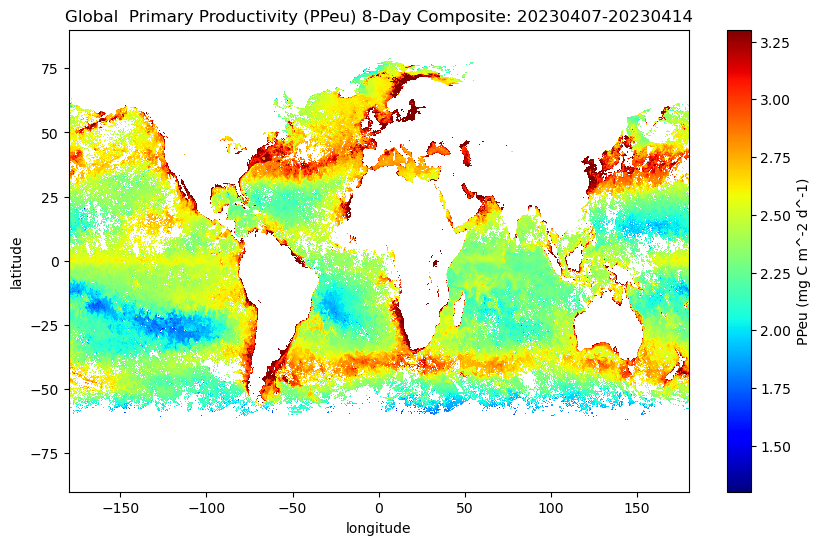

In [23]:
plot_PPeu(
    lon_data,
    lat_data,
    productivity,
    title=f"Global  Primary Productivity (PPeu) 8-Day Composite: {formatted_start_date}-{formatted_end_date}",
)

## Plot SST

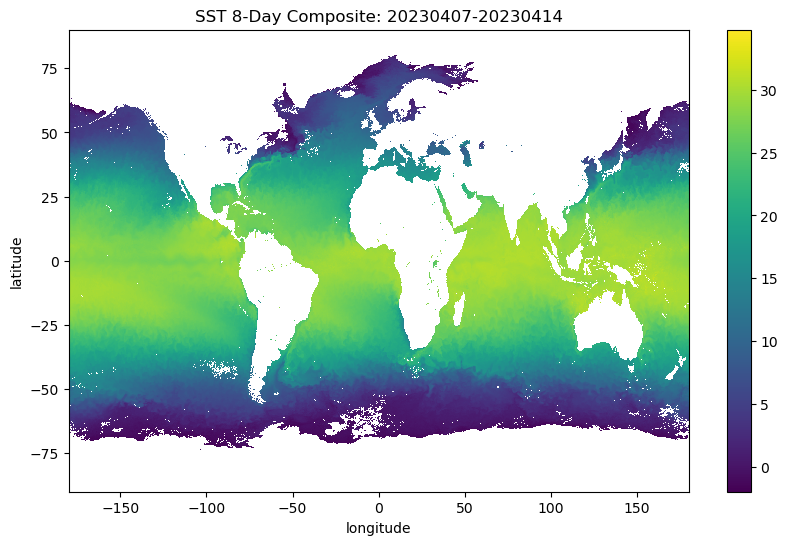

In [24]:
plot_globe(
    lon_data,
    lat_data,
    sea_surface_temp,
    title=f"SST 8-Day Composite: {formatted_start_date}-{formatted_end_date}",
)

## Verify $P_{opt}^b$
### Plotting $P_{opt}^b$ as a function of SST

The plot should show a smooth curve reflecting how productivity peaks within a specific SST range (~20 degrees Celisus).

<function matplotlib.pyplot.show(close=None, block=None)>

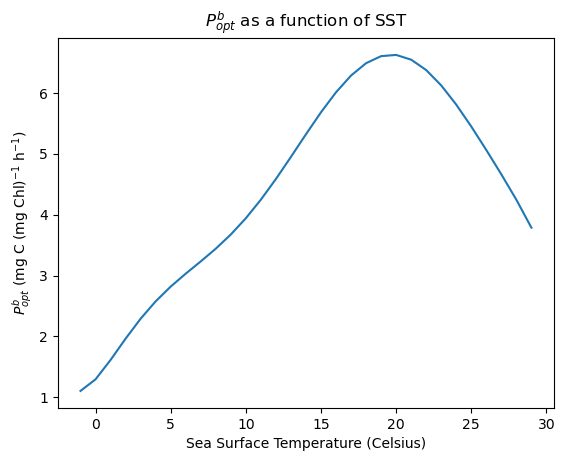

In [25]:
plt.plot(sst_list, PbOpt_plot)
plt.title("$P_{opt}^b$ as a function of SST")
plt.xlabel("Sea Surface Temperature (Celsius)")
plt.ylabel("$P_{opt}^b$ (mg C (mg Chl)$^{-1}$ h$^{-1}$)")
plt.show

## Plot CHL

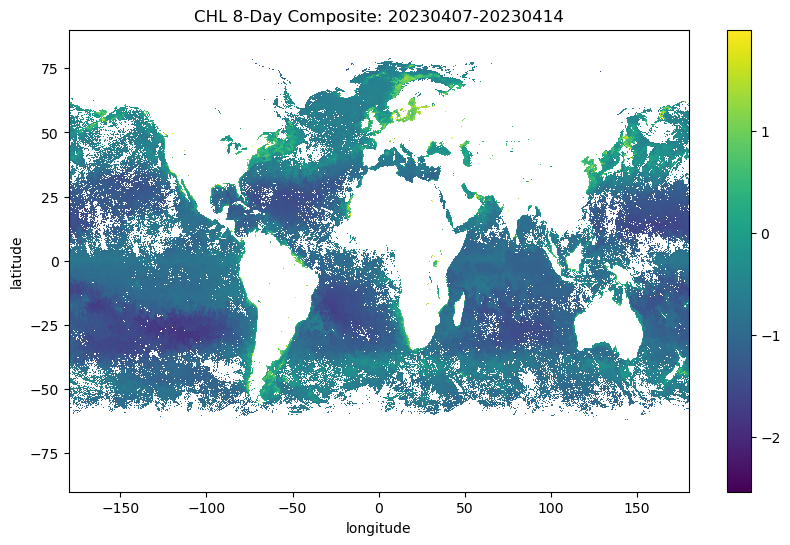

In [26]:
plot_globe(
    lon_data,
    lat_data,
    np.log10(chlor_a),
    title=f"CHL 8-Day Composite: {formatted_start_date}-{formatted_end_date}",
)

## Plot PAR

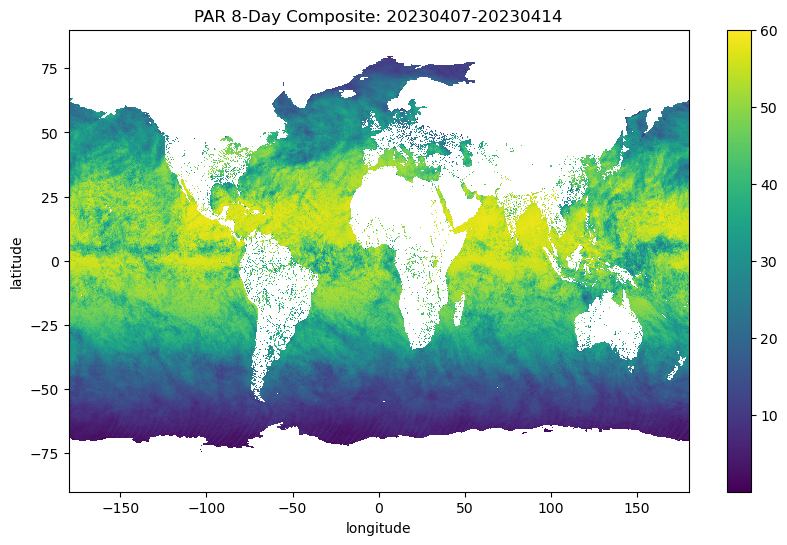

In [27]:
plot_globe(
    lon_data,
    lat_data,
    par,
    title=f"PAR 8-Day Composite: {formatted_start_date}-{formatted_end_date}",
)